In [1]:
%pip install ipycanvas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.0/143.0 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 31.5 MB/s eta 0:00:00a 0:00:01


In [19]:
import torch
import torchvision
from matplotlib import pyplot as plt
import numpy as np
from torchvision import transforms

In [3]:
transform=transforms.ToTensor()


In [4]:

train_data=torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)
print(train_data.data.shape)
test_data=torchvision.datasets.MNIST(
    root="./data",
    train=False,
    transform=transform
)
train_loader=torch.utils.data.DataLoader(train_data,batch_size=64,shuffle=True)
test_loader=torch.utils.data.DataLoader(test_data,batch_size=64,shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 59.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.70MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.8MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.8MB/s]

torch.Size([60000, 28, 28])


In [5]:
import torch.nn as nn
import torch.optim as optim

class NeuralNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.model=nn.Sequential(
            nn.Linear(784,256),
            nn.ReLU(),
            nn.Linear(256,128),
            nn.ReLU(),
            nn.Linear(128,10)
        )
    def forward(self,x):
        return self.model(x)

In [6]:
model=NeuralNet()
lossfunc=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.parameters(),lr=0.001)
model.parameters

<bound method Module.parameters of NeuralNet(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)>

In [7]:
epoch=6
for e in range(epoch):
    total_loss=0
    for images, labels in train_loader:
        images=images.view(-1,784)
        outputs=model(images)
        loss=lossfunc(outputs,labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss+=loss.item()

    print("Epoch:", e+1, "Loss:", total_loss/len(train_loader))

Epoch: 1 Loss: 0.28498313943746245
Epoch: 2 Loss: 0.10717540065289291
Epoch: 3 Loss: 0.06953205168222401
Epoch: 4 Loss: 0.051621012031974424
Epoch: 5 Loss: 0.04089580528596456
Epoch: 6 Loss: 0.03173196865467857


5
0
4
1
9
2
1
3
1
4
[tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
       

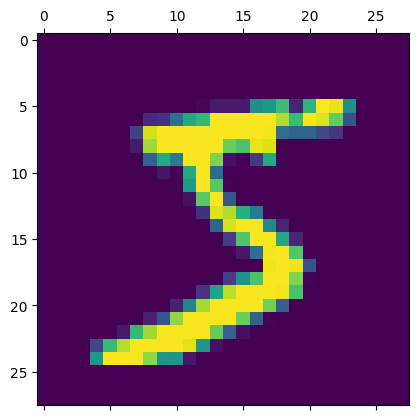

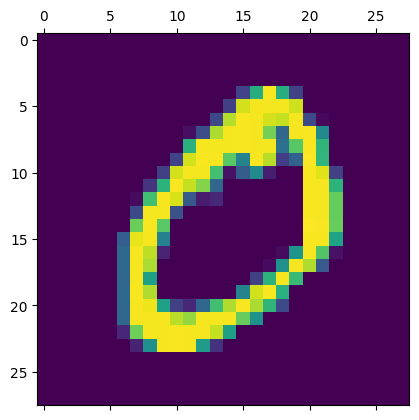

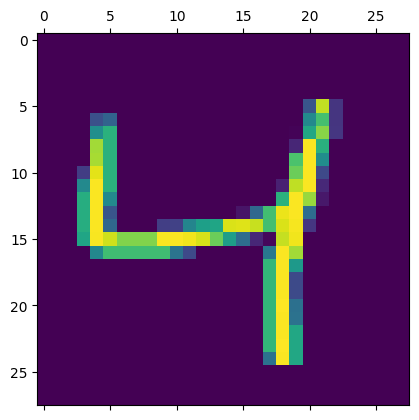

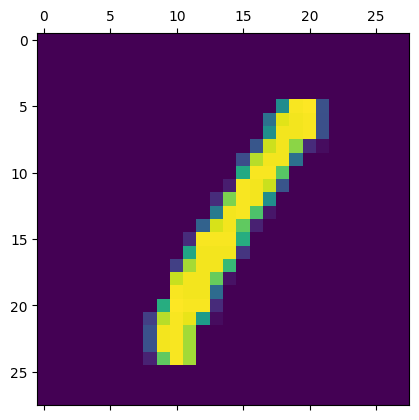

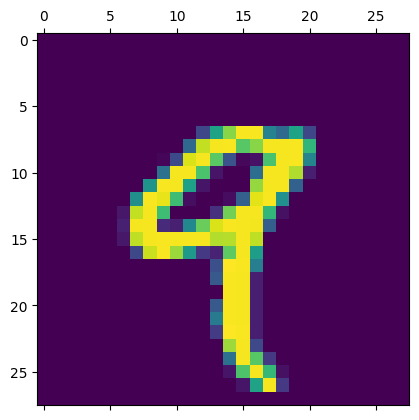

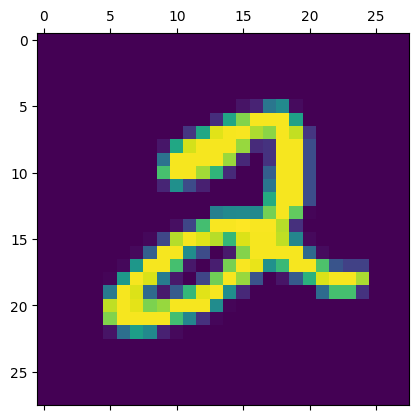

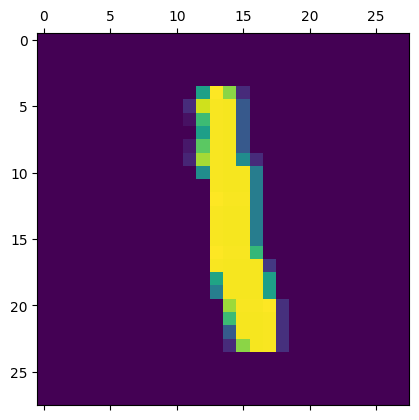

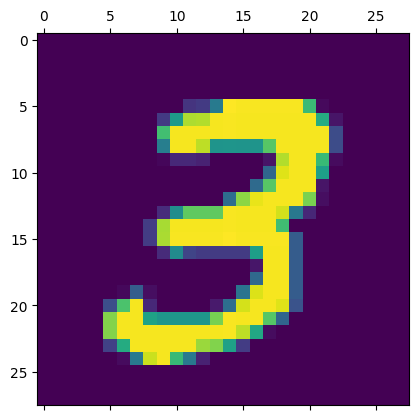

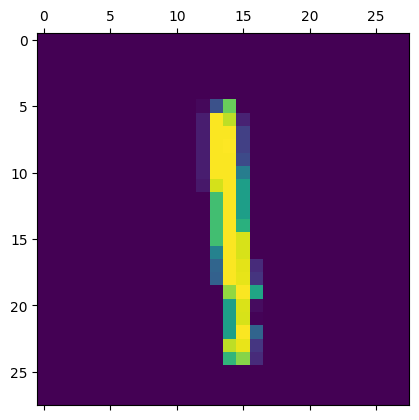

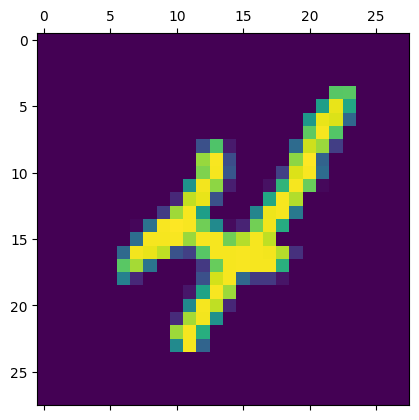

In [26]:
i=10
test_images=[]
for images,labels in train_data:
    test_images.append(images.view(-1,784))
    plt.matshow(images[0])
    print(labels)
    i-=1
    if i==0:
        break;
print(test_images)

In [33]:


# I need to convert the images in to (1,784) and scale them before using them for prediction

out=model(test_images[2])

np.argmax(out.detach().numpy())
# clean_image

np.int64(4)